In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(r"C:\Users\micro\Downloads\archive\AmesHousing.csv")

In [5]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [6]:
df.isnull().sum()[df.isnull().sum()>0]

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

In [7]:
for col in df.select_dtypes(include='object').columns:
    df[col]=df[col].fillna('None')

In [8]:
df['Bsmt Exposure'] = df['Bsmt Exposure'].map({'NONE':0,'NO':1,'MN':2,'AV':3,'GD':4})
df['BsmtFin Type 1'] = df['BsmtFin Type 1'].map({'NONE':0,'UNF':1,'LWQ':2,'REC':3,'BLQ':4,'ALQ':5,'GLQ':6})
df['BsmtFin Type 2'] = df['BsmtFin Type 2'].map({'NONE':0,'UNF':1,'LWQ':2,'REC':3,'BLQ':4,'ALQ':5,'GLQ':6})
df['Garage Finish']  = df['Garage Finish'].map({'NONE':0,'UNF':1,'RFN':2,'FIN':3})
df['Fence']          = df['Fence'].map({'NONE':0,'MNWW':1,'GDWO':2,'MNPRV':3,'GDPRV':4})
df['Lot Shape']      = df['Lot Shape'].map({'IR3':0,'IR2':1,'IR1':2,'REG':3})
df['Land Slope']     = df['Land Slope'].map({'SEV':0,'MOD':1,'GTL':2})
df['Paved Drive']    = df['Paved Drive'].map({'N':0,'P':1,'Y':2})
df['Electrical']     = df['Electrical'].map({'MIX':0,'FUSEP':1,'FUSEF':2,'FUSEA':3,'SBRKR':4})
df['Functional']     = df['Functional'].map({'SAL':0,'SEV':1,'MAJ2':2,'MAJ1':3,'MOD':4,'MIN2':5,'MIN1':6,'TYP':7})

In [9]:


# Impute LotFrontage by neighborhood median, then fill remaining NaNs with global median
df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(
    lambda x: x.fillna(x.median())
)
df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())


C:\Users\micro\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\micro\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [10]:
zero_fill_cols = ['Mas Vnr Area', 'Garage Cars', 'Garage Area',
                   'Bsmt Full Bath', 'Bsmt Half Bath', 'BsmtFin SF 1',
                   'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF']
df[zero_fill_cols] = df[zero_fill_cols].fillna(0)

df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(df['Year Built'])

# now fill anything else genuinely still missing with median
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].fillna(df[col].median())


C:\Users\micro\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\micro\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\micro\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\micro\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\micro\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out,

In [11]:
df.isnull().sum().sort_values(ascending=False).head(10)


Land Slope       2930
Bsmt Exposure    2930
Functional       2930
Garage Finish    2930
Electrical       2930
Fence            2930
PID                 0
MS SubClass         0
Lot Frontage        0
Lot Area            0
dtype: int64

In [12]:
pd.set_option('display.max_columns', None)
df.head(3)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,None,2.0,Lvl,AllPub,Corner,NaN,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,NaN,4.0,639.0,5.0,0.0,441.0,1080.0,GasA,Fa,Y,NaN,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,NaN,2,Gd,Attchd,1960.0,NaN,2.0,528.0,TA,TA,1,210,62,0,0,0,0,None,NaN,None,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,None,2.0,Lvl,AllPub,Inside,NaN,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,NaN,6.0,468.0,5.0,144.0,270.0,882.0,GasA,TA,Y,NaN,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,NaN,0,None,Attchd,1961.0,NaN,1.0,730.0,TA,TA,2,140,0,0,0,120,0,None,NaN,None,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,None,2.0,Lvl,AllPub,Corner,NaN,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,NaN,5.0,923.0,5.0,0.0,406.0,1329.0,GasA,TA,Y,NaN,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,NaN,0,None,Attchd,1958.0,NaN,1.0,312.0,TA,TA,2,393,36,0,0,0,0,None,NaN,Gar2,12500,6,2010,WD,Normal,172000


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

<Axes: xlabel='SalePrice', ylabel='Count'>

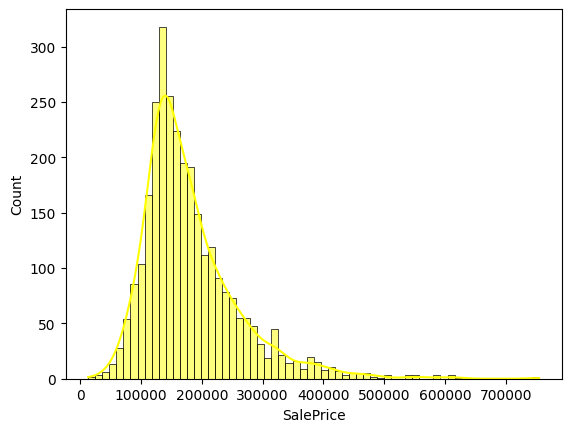

In [15]:
sns.histplot(x='SalePrice',data=df,kde=True,color='yellow')

In [16]:
#histogram is left skewed most of the values belong to the smaller portion of amount 

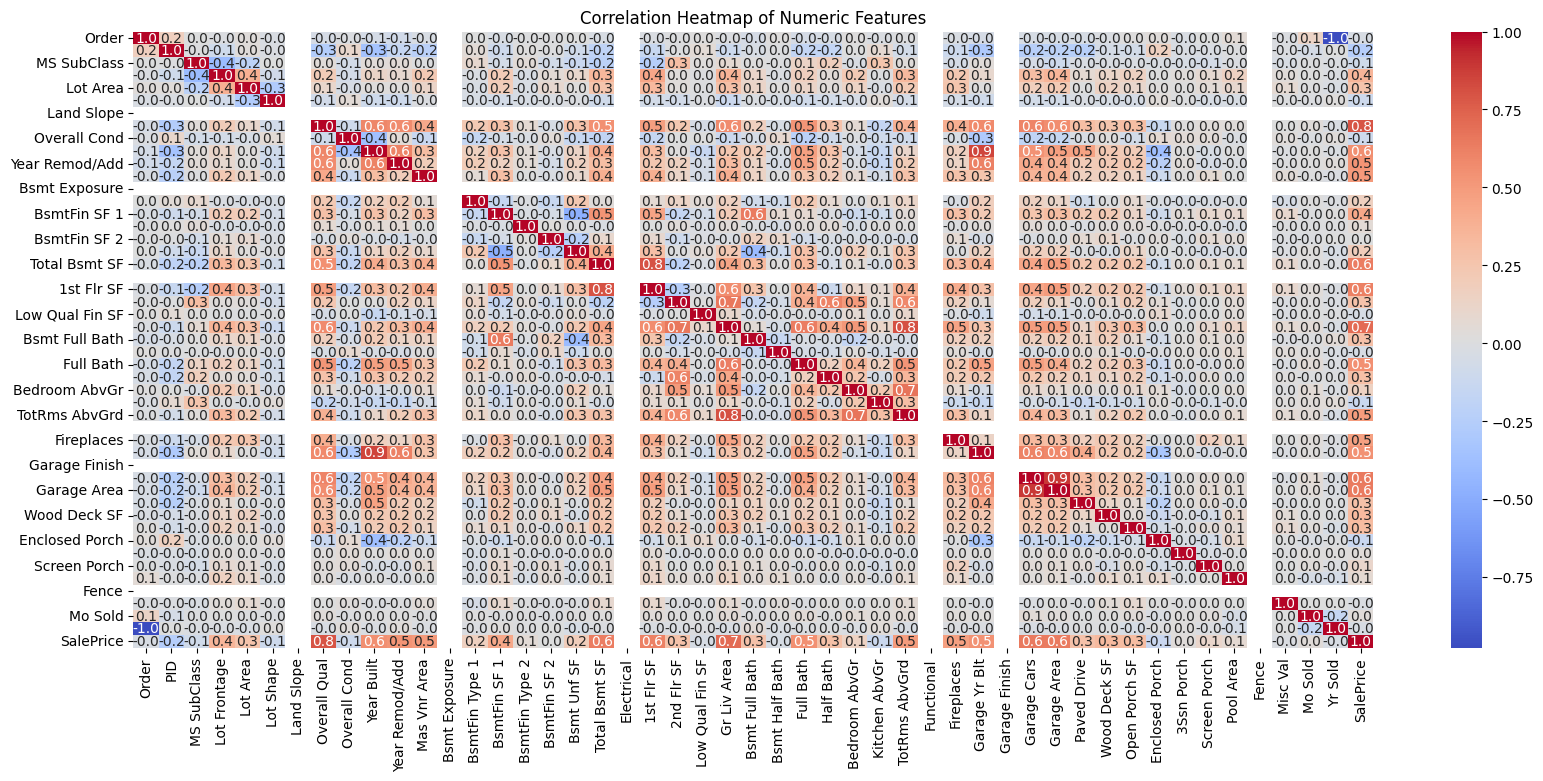

In [17]:

df_corr = df.select_dtypes(include=['int64', 'float'])

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Display correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True,fmt='.1f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


In [18]:
#gearge area ,garagecars,garage liv area,first flr and most important 1 is overall qaulity have best realation with sales price 

In [19]:
corr_matrix

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Lot Shape,Land Slope,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Functional,Fireplaces,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Fence,Misc Val,Mo Sold,Yr Sold,SalePrice
Order,1.000000,0.173593,0.011797,-0.005470,0.031354,-0.020889,NaN,-0.048500,-0.011054,-0.052319,-0.075566,-0.031045,NaN,0.004693,-0.032268,-0.000501,-0.002758,0.005842,-0.028572,NaN,-0.013201,-0.000417,0.013589,-0.009342,-0.042499,0.024987,-0.044985,-0.039749,0.015424,-0.017685,0.002612,NaN,-0.019156,-0.042545,NaN,-0.036869,-0.036085,-0.034820,-0.011292,0.016355,0.027908,-0.024975,0.004307,0.052518,NaN,-0.006083,0.133365,-0.975993,-0.031408
PID,0.173593,1.000000,-0.001281,-0.095493,0.034868,-0.013110,NaN,-0.263147,0.104451,-0.343388,-0.157111,-0.225672,NaN,0.043549,-0.098674,0.016461,-0.001245,-0.088102,-0.190240,NaN,-0.141902,-0.003289,0.056940,-0.107579,-0.038306,0.004154,-0.171431,-0.166636,0.006345,0.076470,-0.068981,NaN,-0.108056,-0.284972,NaN,-0.238044,-0.211172,-0.236632,-0.051135,-0.071311,0.162519,-0.024894,-0.025735,-0.002845,NaN,-0.008260,-0.050455,0.009579,-0.246521
MS SubClass,0.011797,-0.001281,1.000000,-0.403253,-0.204613,0.008280,NaN,0.039419,-0.067349,0.036579,0.043397,0.003634,NaN,0.085933,-0.059767,0.049706,-0.070847,-0.129987,-0.218489,NaN,-0.247828,0.304237,0.025765,0.068061,0.014187,-0.003179,0.134631,0.175879,-0.019208,0.257698,0.031898,NaN,-0.049955,0.036699,NaN,-0.046074,-0.103374,-0.024641,-0.017310,-0.014823,-0.022866,-0.037956,-0.050614,-0.003434,NaN,-0.029254,0.000350,-0.017905,-0.085092
Lot Frontage,-0.005470,-0.095493,-0.403253,1.000000,0.389074,-0.073076,NaN,0.204169,-0.057971,0.122510,0.087248,0.220959,NaN,-0.018496,0.211500,-0.029008,0.054440,0.103421,0.342480,NaN,0.437517,0.029794,0.003243,0.364727,0.109310,-0.010853,0.172648,0.045950,0.226307,0.003637,0.332738,NaN,0.240139,0.094425,NaN,0.299869,0.351662,0.068045,0.117934,0.156018,0.008033,0.029310,0.074503,0.155686,NaN,0.038287,0.007422,-0.007855,0.353417
Lot Area,0.031354,0.034868,-0.204613,0.389074,1.000000,-0.274936,NaN,0.097188,-0.034759,0.023258,0.021682,0.125950,NaN,-0.033579,0.191692,-0.028164,0.083198,0.023883,0.253765,NaN,0.332235,0.032996,0.000812,0.285599,0.124208,0.026448,0.127433,0.035497,0.136569,-0.020301,0.216597,NaN,0.256989,0.014518,NaN,0.179456,0.212749,0.004334,0.157212,0.103760,0.021868,0.016243,0.055044,0.093775,NaN,0.069188,0.003859,-0.023085,0.266549
Lot Shape,-0.020889,-0.013110,0.008280,-0.073076,-0.274936,1.000000,NaN,-0.076073,0.052480,-0.088500,-0.096927,-0.006940,NaN,-0.041441,-0.064673,-0.036179,-0.019612,-0.008619,-0.082930,NaN,-0.068034,-0.074755,-0.004102,-0.116470,-0.013422,-0.034908,-0.085420,-0.066230,-0.043524,0.035463,-0.063611,NaN,-0.056909,-0.083272,NaN,-0.071290,-0.066814,-0.021293,-0.034727,-0.047315,0.040813,-0.000631,-0.040415,-0.031943,NaN,-0.001431,-0.009728,0.023306,-0.099641
Land Slope,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Overall Qual,-0.048500,-0.263147,0.039419,0.204169,0.097188,-0.076073,NaN,1.000000,-0.094812,0.597027,0.569609,0.423089,NaN,0.221601,0.284458,0.067847,-0.041122,0.270527,0.547766,NaN,0.477837,0.241402,-0.048680,0.570556,0.168373,-0.041433,0.522263,0.268853,0.063291,-0.159744,0.380693,NaN,0.393007,0.576507,NaN,0.599547,0.563562,0.299016,0.255663,0.298412,-0.140332,0.018240,0.041615,0.030399,NaN,0.005179,0.031103,-0.020719,0.799262
Overall Cond,-0.011054,0.104451,-0.067349,-0.057971,-0.034759,0.052480,NaN,-0.094812,1.000000,-0.368773,0.047680,-0.1324

In [20]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

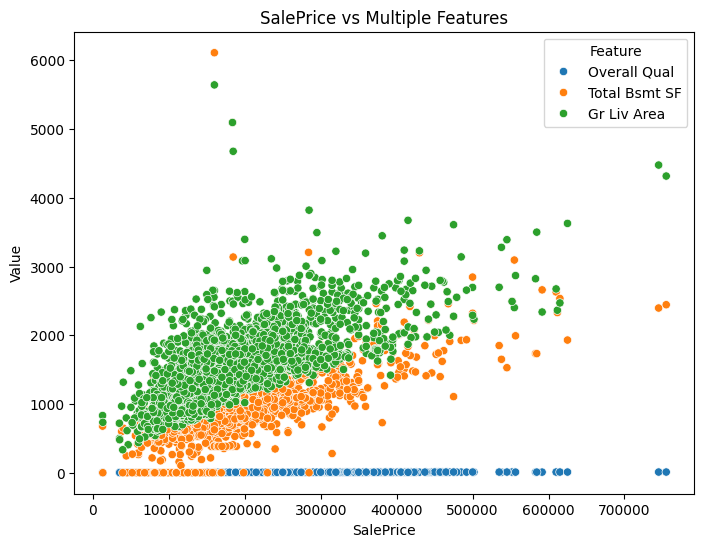

In [21]:



# Melt the DataFrame to long format for multiple y variables
df_melted = df.melt(id_vars='SalePrice', value_vars=['Overall Qual', 'Total Bsmt SF', 'Gr Liv Area'],
                    var_name='Feature', value_name='Value')

plt.figure(figsize=(8,6))
sns.scatterplot(x='SalePrice', y='Value', hue='Feature', data=df_melted)
plt.title('SalePrice vs Multiple Features')
plt.show()



In [22]:
#see other have positive relation ship and quality is neutral one it is just styed in one single line 

In [23]:
df['Overall Qual']

0       6
1       5
2       6
3       7
4       5
       ..
2925    6
2926    5
2927    5
2928    5
2929    7
Name: Overall Qual, Length: 2930, dtype: int64

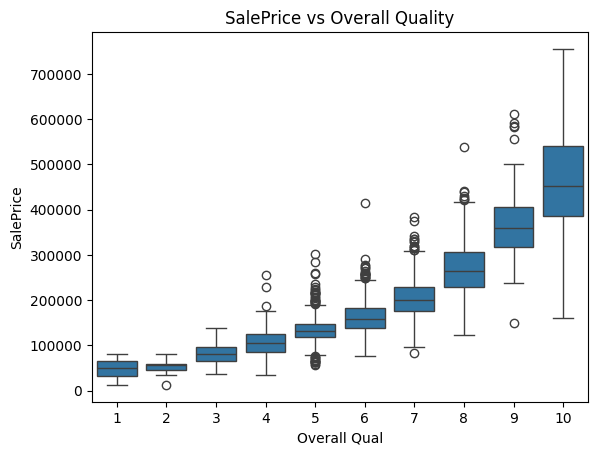

In [24]:
sns.boxplot(x='Overall Qual', y='SalePrice', data=df)
plt.title('SalePrice vs Overall Quality')
plt.show()


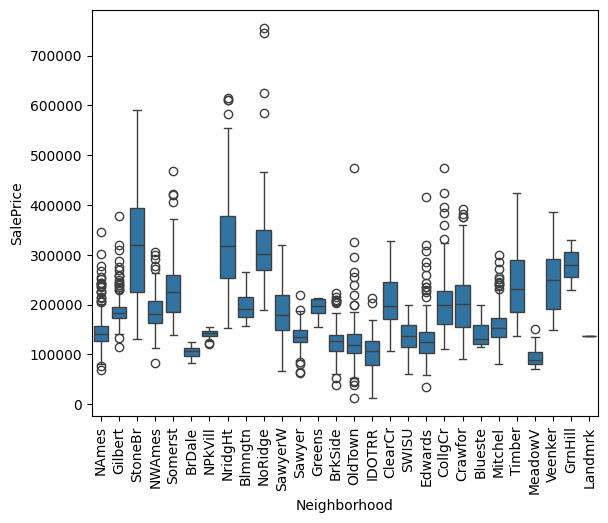

In [25]:
sns.boxplot(x='Neighborhood',y='SalePrice',data=df)
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

In [26]:
import scipy.stats as st

In [27]:


# Group SalePrice by Neighborhood
groups = [group["SalePrice"].values for _, group in df.groupby("Neighborhood")]
# Perform one-way ANOVA
f_stat, p_val = st.f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_val)


F-statistic: 144.3950774998117
p-value: 0.0


In [28]:
#yes we can reject the null hypothesis

In [29]:
st.pearsonr(df['Overall Qual'],df['SalePrice'])

PearsonRResult(statistic=np.float64(0.7992617947690233), pvalue=np.float64(0.0))

In [30]:
#0.7 relationship getting mean it contribute a lot o.8 i previsoly mentioned bcz it is 0.799

In [31]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [32]:
y=np.log1p(df['SalePrice'])

In [33]:
df['TotalSF'] = df['Total Bsmt SF'] + df['1st Flr SF'] + df['2nd Flr SF']


In [34]:
df['Houseage']=df['Yr Sold']- df['Year Built']

In [35]:
df['Exter Qual'].value_counts()

Exter Qual
TA    1799
Gd     989
Ex     107
Fa      35
Name: count, dtype: int64

In [36]:
df['Neighborhood'].value_counts()

Neighborhood
NAmes      443
CollgCr    267
OldTown    239
Edwards    194
Somerst    182
NridgHt    166
Gilbert    165
Sawyer     151
NWAmes     131
SawyerW    125
Mitchel    114
BrkSide    108
Crawfor    103
IDOTRR      93
Timber      72
NoRidge     71
StoneBr     51
SWISU       48
ClearCr     44
MeadowV     37
BrDale      30
Blmngtn     28
Veenker     24
NPkVill     23
Blueste     10
Greens       8
GrnHill      2
Landmrk      1
Name: count, dtype: int64

In [37]:
# Clean all object columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.upper()

# Map Exter Qual
qual_mapping = {'NONE': 0, 'PO': 1, 'FA': 2, 'TA': 3, 'GD': 4, 'EX': 5}

qual_cols = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond',
             'Kitchen Qual', 'Heating QC', 'Fireplace Qu',
             'Garage Qual', 'Garage Cond', 'Pool QC']

for col in qual_cols:
    df[col] = df[col].map(qual_mapping)

# One-hot encode remaining categorical columns
df = pd.get_dummies(df, drop_first=True)

# Ensure all columns are numeric
df = df.apply(pd.to_numeric, errors='coerce').fillna(0)

# Define features and target
x = df.drop(['SalePrice','PID','Order'], axis=1)




In [38]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler






In [39]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [40]:


# Create the scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test in place
x_train[:] = scaler.fit_transform(x_train)
x_test[:] = scaler.transform(x_test)


C:\Users\micro\AppData\Local\Temp\ipykernel_24540\2454653685.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.87181667  0.06290638  0.76394867 ...  0.06290638 -0.17077438
  0.64710829]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_train[:] = scaler.fit_transform(x_train)
C:\Users\micro\AppData\Local\Temp\ipykernel_24540\2454653685.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.03380992  2.30708197 -0.03551382 ... -0.16608596 -0.35032808
 -0.36374558]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_train[:] = scaler.fit_transform(x_train)
C:\Users\micro\AppData\Local\Temp\ipykernel_24540\2454653685.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.67394069 -0.76674

In [41]:
r=Ridge(alpha =0.1)

In [42]:
r.fit(x_train,y_train)
yhat=np.expm1(r.predict(x_test))

In [43]:
y_test_d = np.expm1(y_test)


In [44]:
r_mse=mean_squared_error

In [45]:
print('mse for ridge:',r_mse(y_test_d,yhat))

mse for ridge: 1439431934.4980428


In [46]:
l=Lasso()

In [47]:
l.fit(x_train,y_train)
l_yhat=np.expm1(l.predict(x_test))

In [48]:
l_mse=mean_squared_error

In [49]:
print('mse for Lasso:',l_mse(y_test_d,l_yhat))

mse for Lasso: 8640724537.42682


In [50]:
r_rmse = np.sqrt(mean_squared_error(y_test_d, yhat))
l_rmse = np.sqrt(mean_squared_error(y_test_d, l_yhat))
print("RMSE for Ridge:", r_rmse)
print("RMSE for Lasso:", l_rmse)


RMSE for Ridge: 37939.84626350037
RMSE for Lasso: 92955.49761809046


In [51]:
ridge_coef = pd.Series(r.coef_, index=x.columns)
ridge_coef = ridge_coef.sort_values(key=abs, ascending=False)
print(ridge_coef.head(10))


Misc Feature_NONE    0.422874
Misc Feature_SHED    0.399282
MS Zoning_RL         0.394083
Roof Matl_COMPSHG    0.356669
MS Zoning_RM         0.332783
Roof Matl_TAR&GRV    0.256997
MS Zoning_FV         0.198077
Roof Matl_WDSHAKE    0.168524
Roof Matl_WDSHNGL    0.154726
Misc Feature_GAR2    0.101366
dtype: float64


In [52]:
from sklearn.linear_model import Lasso

for a in [0.1, 0.01, 0.001]:
    lasso = Lasso(alpha=a)
    lasso.fit(x_train, y_train)
    print(f"alpha={a}, nonzero={np.sum(lasso.coef_ != 0)}")



alpha=0.1, nonzero=5
alpha=0.01, nonzero=50
alpha=0.001, nonzero=147


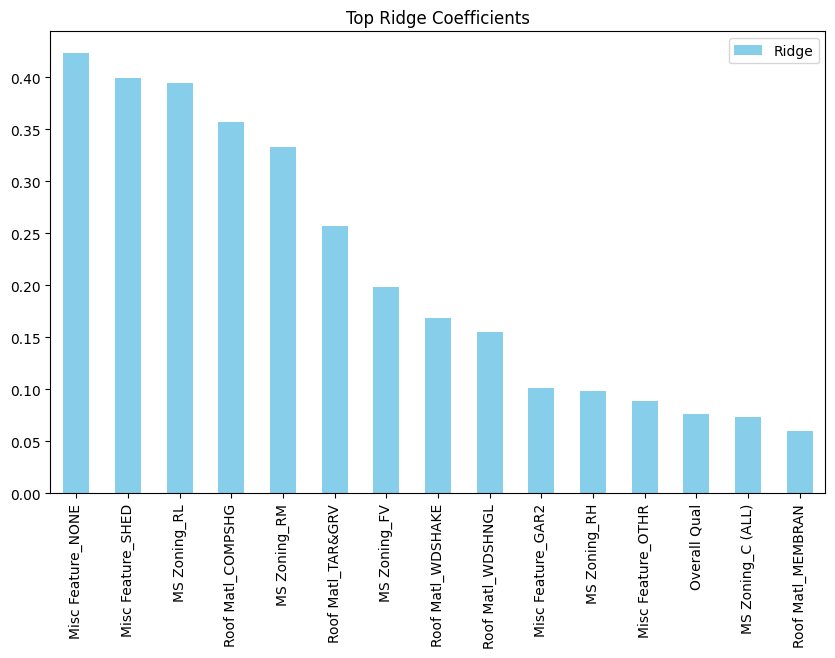

In [54]:
plt.figure(figsize=(10,6))
ridge_coef.head(15).plot(kind='bar', color='skyblue', label='Ridge')
plt.title('Top Ridge Coefficients')
plt.legend()
plt.show()




In [55]:
xg=GradientBoostingRegressor()

In [56]:
xg.fit(x_train,y_train)
xg_yhat=np.expm1(xg.predict(x_test))
xg_mse=mean_squared_error
print('xg mse:',np.sqrt(xg_mse(y_test_d,xg_yhat)))

xg mse: 26828.840501281313


In [57]:
xg_importance=pd.Series(xg.feature_importances_,index=x.columns)
xg_importance=xg_importance.sort_values(ascending=False)
print(xg_importance.head(10))

Overall Qual      0.362673
TotalSF           0.357277
Kitchen Qual      0.035501
Central Air_Y     0.023341
Bsmt Qual         0.021260
Gr Liv Area       0.019406
Garage Cars       0.017130
Year Remod/Add    0.016458
Houseage          0.014782
Lot Area          0.011420
dtype: float64


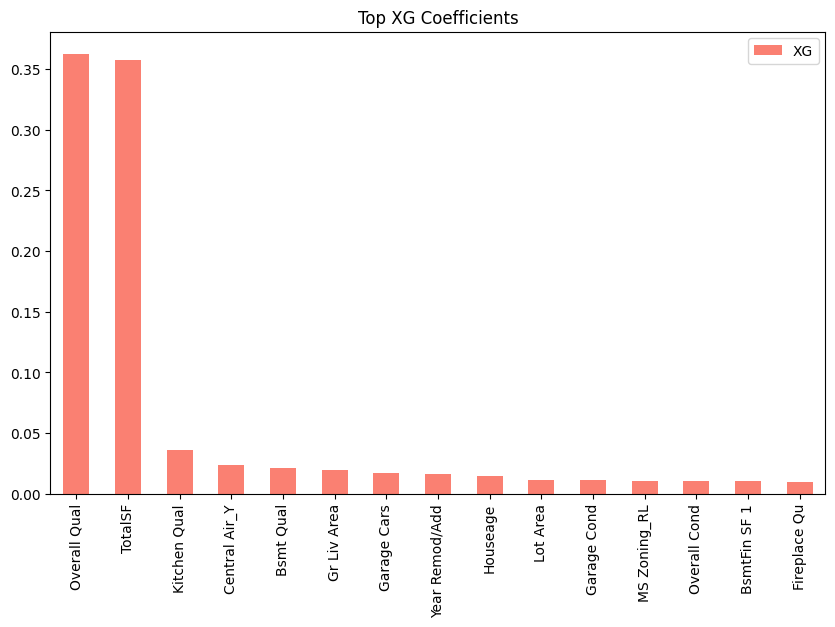

In [58]:
plt.figure(figsize=(10,6))
xg_importance.head(15).plot(kind='bar', color='salmon', label='XG')
plt.title('Top XG Coefficients')
plt.legend()
plt.show()


In [60]:
#Gradient Boosting achieved the lowest RMSE ($26,829), confirming it as the best-performing model, and its feature importances (TotalSF, Overall Qual) matched what our correlation and ANOVA analysis had already identified as the strongest predictors. Ridge (RMSE $37,940) performed reasonably but its top coefficients were dominated by rare one-hot categorical features rather than TotalSF/Overall Qual — likely because standardizing rare binary dummies inflates their coefficient magnitude disproportionately to their real-world importance. Lasso performed worst (RMSE $92,955), likely because its default regularization strength (alpha=1.0) was too aggressive and zeroed out genuinely predictive features — [confirm/refute once you've run the alpha=0.01 test]. Overall, Gradient Boosting is both the most accurate and the most interpretable model for this dataset.